**Goal:** open Unit VII by squeezing 64-pixel digit images down to a handful of numbers with **PCA**
and losing almost nothing. You will project the digits onto their first two principal components and
watch the classes separate by eye, choose how many components keep **95%** of the variance (28 of 64),
confirm a classifier on those 28 nearly matches the full 64 (0.954 on 28 vs 0.957 on all 64),
**reconstruct** the images to see what compression costs, and finally open PCA's box with a by-hand SVD. Pairs with the
concept note [Principal Component Analysis](l26_concept_pca.qmd).

> **Previously:** L25 -- Gaussian Mixtures & EM  |  **Next:** L27 -- Factor Analysis & ICA

> This page is the read-only view. To run the lab, open the notebook
> (`l26_lab_pca.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

We use scikit-learn's **digits** dataset: 1797 handwritten digits, each an 8x8 grayscale image
flattened to **64 features** (pixel intensities 0-16), in 10 classes. It is bundled with
scikit-learn (no download) and seeded, so everyone sees the same split. Sixty-four features is small
enough to inspect yet big enough that compression clearly helps -- the border pixels are almost always
blank and neighbouring pixels move together, so the data really lives in far fewer than 64 dimensions.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, loads the digits, and splits them.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, DATA, SPLIT (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("digits:", X.shape, "pixels", int(X.min()), "to", int(X.max()), "| 10 classes")
print("train/test:", Xtr.shape[0], "/", Xte.shape[0])

digits: (1797, 64) pixels 0 to 16 | 10 classes
train/test: 1257 / 540


~~~text
digits: (1797, 64) pixels 0 to 16 | 10 classes
train/test: 1257 / 540
~~~

## Step 1: Project 64 Dimensions Down to 2

PCA finds the orthogonal axes -- **principal components** -- along which the data varies most, ordered
by how much variance each captures. Keep the top two and you can plot 64-dimensional data on a flat
page. Fit `PCA(n_components=2)` and read `explained_variance_ratio_`, the fraction of the total
variance each component holds. PCA is unsupervised -- it never sees the labels `y`; we only colour the
plot by digit afterward to check whether the structure it found lines up with the classes:

In [3]:
pca2 = PCA(n_components=2)
X2 = pca2.fit_transform(Xtr)
print("2 components keep variance fractions:", pca2.explained_variance_ratio_.round(3))
print("together:", round(pca2.explained_variance_ratio_.sum(), 3), "of the total")

2 components keep variance fractions: [0.146 0.137]
together: 0.283 of the total


~~~text
2 components keep variance fractions: [0.146 0.137]
together: 0.283 of the total
~~~

Just two of the 64 axes already hold 28% of all the variance. Plot the projection, coloured by the
true digit, and the classes fall into visible neighbourhoods even though PCA was never told they exist:

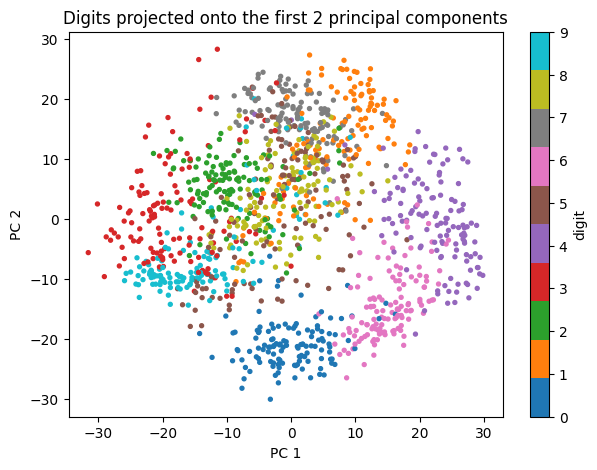

In [4]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(X2[:, 0], X2[:, 1], c=ytr, s=8, cmap="tab10")
plt.colorbar(sc, label="digit")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("Digits projected onto the first 2 principal components")
plt.show()

The 0s, 6s, and 4s drift into their own corners while 1s, 8s, and 9s overlap in the middle -- 2
numbers per point instead of 64, and the class structure is already legible. That is PCA as a
**visualization** tool.

## Step 2: How Many Components Keep 95% of the Variance?

Two components are enough to *look* at, but to *compress* without throwing away much, choose the
number of components that preserves a target fraction of the variance -- say 95%. Fit a full PCA, take
the **cumulative** sum of `explained_variance_ratio_`, and find where it first crosses your target:

In [5]:
# Uncomment and complete: how many components keep 95% of the variance?
# pca_full = PCA().fit(Xtr)
# cumvar = np.cumsum(pca_full.explained_variance_ratio_)
# d95 = np.argmax(cumvar >= ____) + 1                      # <- the variance target to keep (0-1)
# print(f"components to keep 95% of the variance: {d95} of {Xtr.shape[1]}")
# for target in (0.80, 0.90, 0.95, 0.99):
#     print(f"  {int(target*100)}% variance -> {np.argmax(cumvar >= target) + 1} components")

<details><summary>Expected Output</summary>

~~~text
components to keep 95% of the variance: 28 of 64
  80% variance -> 13 components
  90% variance -> 21 components
  95% variance -> 28 components
  99% variance -> 41 components
~~~

The blank is `np.argmax(cumvar >= 0.95) + 1` -- the target is `0.95`, and the `+ 1` turns a 0-based
index into a count. Just **28** of the 64 components hold 95% of the variance, so we can more than
halve the dimensionality. The ladder shows the trade-off: 80% needs only 13 components, but the last
4% (95% -> 99%) costs another 13, because the tail components each carry very little.
</details>

Instead of reading the number off by hand, you can pass the fraction straight to `PCA` and let it pick:

In [6]:
pca95 = PCA(n_components=0.95).fit(Xtr)
print("PCA(n_components=0.95) chose", pca95.n_components_, "components")

PCA(n_components=0.95) chose 28 components


~~~text
PCA(n_components=0.95) chose 28 components
~~~

## Step 3: Does the Compression Cost Accuracy?

Halving the features only helps if the model stays accurate. Train the same logistic-regression
classifier twice -- once on all 64 raw features, once on the 28 PCA components -- and compare:

In [7]:
def accuracy(Xa, Xb):
    clf = LogisticRegression(max_iter=5000, random_state=42).fit(Xa, ytr)
    return clf.score(Xb, yte)

acc_full = accuracy(Xtr, Xte)
Xtr95, Xte95 = pca95.transform(Xtr), pca95.transform(Xte)
acc_pca = accuracy(Xtr95, Xte95)
print(f"LogReg on all 64 features:   {acc_full:.3f}")
print(f"LogReg on 28 PCA components: {acc_pca:.3f}")

LogReg on all 64 features:   0.957
LogReg on 28 PCA components: 0.954


~~~text
LogReg on all 64 features:   0.957
LogReg on 28 PCA components: 0.954
~~~

The 28-component model scores **0.954** against the full model's **0.957** -- a 0.003 drop for less
than half the features. Fewer features also means a smaller, faster model that is less prone to
overfitting, so the compression is essentially free here. PCA earns its keep as a **preprocessing**
step, not just a plotting trick.

## Step 4: Reconstruction -- What Did We Throw Away?

PCA is **lossy**: projecting onto `d` components and back (`inverse_transform`) returns an
approximation, not the original. The reconstruction error -- mean squared error between the original
pixels and their reconstruction -- shows exactly how much each component buys. Sweep `d` and watch it
fall:

In [8]:
# Uncomment and complete: reconstruct from d components and measure the error.
# for d in (____, ____, ____, ____):                       # try 2, 10, 28, and all 64
#     p = PCA(n_components=d).fit(Xtr)
#     X_rec = p.inverse_transform(p.transform(Xtr))
#     print(f"  d={d:2d}: reconstruction MSE {np.mean((Xtr - X_rec)**2):.3f}")

<details><summary>Expected Output</summary>

~~~text
  d= 2: reconstruction MSE 13.426
  d=10: reconstruction MSE 4.909
  d=28: reconstruction MSE 0.935
  d=64: reconstruction MSE 0.000
~~~

The blank is `for d in (2, 10, 28, 64):`. At 2 components the error is large (13.4) -- you can look at
the data but not rebuild it; by 28 it is down to 0.935 (the 5% of variance we dropped); at the full 64
it is exactly 0, because no information was discarded. Error falls steeply at first, then crawls -- the
same diminishing return the variance ladder showed.
</details>

Reconstruct the first six training digits from just 28 components and put them under the originals --
the compressed versions are visibly the same digits, a little smoothed:

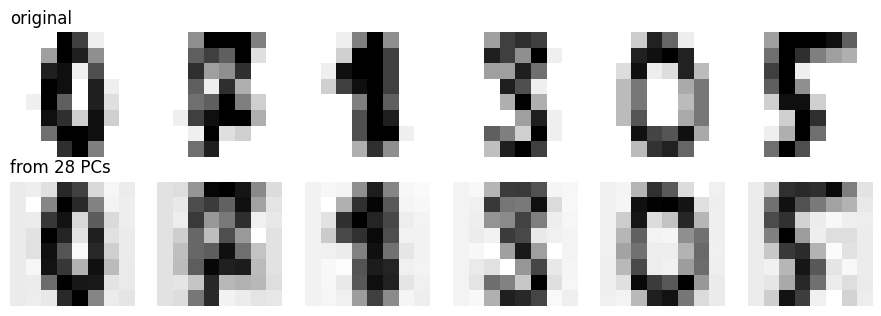

In [9]:
p28 = PCA(n_components=28).fit(Xtr)
X_rec28 = p28.inverse_transform(p28.transform(Xtr))
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for i in range(6):
    axes[0, i].imshow(Xtr[i].reshape(8, 8), cmap="gray_r"); axes[0, i].axis("off")
    axes[1, i].imshow(X_rec28[i].reshape(8, 8), cmap="gray_r"); axes[1, i].axis("off")
axes[0, 0].set_title("original", loc="left")
axes[1, 0].set_title("from 28 PCs", loc="left")
plt.tight_layout(); plt.show()

## Your Turn

### Exercise 1 -- Open the box: PCA is an SVD

PCA is not magic -- it is the **singular value decomposition** of the *centered* data. Center `Xtr`
(subtract its column mean), take the SVD, and confirm the singular vectors are exactly scikit-learn's
principal components and the squared singular values are its variances.

In [10]:
# TODO: Xc = Xtr - Xtr.mean(axis=0)
#       U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
#       pca = PCA().fit(Xtr)
#       compare np.abs(Vt[:3]) to np.abs(pca.components_[:3]) with np.allclose(..., atol=1e-6)
#       compare S**2 / (len(Xtr) - 1) to pca.explained_variance_ with np.allclose

<details><summary>Expected Output</summary>

~~~text
hand-SVD top-3 components == sklearn (up to sign): True
hand-SVD variances == sklearn explained_variance_: True
~~~

The principal components are the rows of `Vt` from the SVD of the centered matrix, and each
component's variance is its squared singular value divided by `n - 1`. They match scikit-learn exactly
(up to a sign flip, since a component and its negation describe the same axis). That is the whole
algorithm: center, take the SVD, keep the top rows.
</details>

### Exercise 2 -- The accuracy-vs-compression curve

Step 3 compared 64 features to 28. Fill in the middle: train the classifier on 2, 10, 28, and 64
components and watch accuracy climb and then flatten, so you can see where the returns stop.

In [11]:
# TODO: for d in (2, 10, 28, 64):
#           if d == 64: use the raw Xtr / Xte (all features)
#           else: fit PCA(n_components=d) on Xtr, transform Xtr and Xte
#           print d and accuracy(...) reusing the Step 3 helper

<details><summary>Expected Output</summary>

~~~text
   2 components: accuracy 0.600
  10 components: accuracy 0.924
  28 components: accuracy 0.954
  64 components: accuracy 0.957
~~~

Two components are great for a picture but lose too much to classify well (0.600). By 10 components
accuracy is already 0.924, and by 28 it is 0.954 -- within 0.003 of the full 64. The curve is the
compression story in one line: most of the predictive signal lives in the first couple dozen
components, and the rest is barely worth its dimensions.
</details>

## Summary

- High-dimensional data is mostly empty space; **PCA** finds the orthogonal **principal components**
  (axes of maximum variance, via the SVD of the centered data) and projects onto the top few.
- Two components held 28% of the digits' variance and made the classes legible on a flat plot --
  PCA as **visualization**; PCA never sees the labels, it finds variance.
- Choosing `d` by **cumulative explained variance**: just **28** of 64 components keep 95% (13 keep
  80%, 41 keep 99%) -- pass the fraction to `PCA(n_components=0.95)` and it picks 28 for you.
- The compression is nearly free: a classifier on 28 components scored **0.954** vs **0.957** on all
  64, and the accuracy-vs-components curve (0.600 -> 0.924 -> 0.954 -> 0.957) shows the signal
  concentrates in the first couple dozen components.
- PCA is **lossy** -- reconstruction MSE fell from 13.4 (2 PCs) to 0.935 (28 PCs) to 0 (all 64) -- and
  it is exactly the **SVD** of the centered matrix (the by-hand SVD matched scikit-learn). PCA is the
  **linear autoencoder** L20 pointed at: project = encode, reconstruct = decode.
- Next (L27): nonlinear and signal-separating cousins -- factor analysis and ICA (with t-SNE / LLE
  named as manifold methods) -- continue Unit VII where PCA's straight-line projection is not enough.